In [1]:
import pandas as pd
import numpy as np

# --- Load preprocessed fraud dataset ---
df = pd.read_csv(r'C:\CareerShieldAI\datasets\fraud_features.csv')  # load data

# --- Fill any remaining empty text with empty string ---
df['clean_description'] = df['clean_description'].fillna('')   # fill empty descriptions
df['clean_requirements'] = df['clean_requirements'].fillna('')  # fill empty requirements

# --- Combine description and requirements into one text column ---
df['combined_text'] = df['clean_description'] + ' ' + df['clean_requirements']  # merge text

print("Data loaded successfully.")
print(f"Total rows: {len(df)}")           # total job postings
print(f"Fraud cases: {df['fraudulent'].sum()}")   # total fake jobs
print(f"Real cases: {(df['fraudulent']==0).sum()}")  # total real jobs
print(f"\nSample combined text:")
print(df['combined_text'][0][:200])       # preview first row text

Data loaded successfully.
Total rows: 17880
Fraud cases: 866
Real cases: 17014

Sample combined text:
food52 a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small team of editor


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Convert text to numbers using TF-IDF ---
# TF-IDF gives higher score to important/rare words
# and lower score to common words like 'the', 'and'
tfidf = TfidfVectorizer(max_features=500)              # use top 500 words only

# --- Learn vocabulary from text and convert to numbers ---
text_features = tfidf.fit_transform(df['combined_text'])  # returns a matrix of numbers

print("TF-IDF conversion done.")
print(f"Text matrix shape: {text_features.shape}")    # rows x 500 features
print(f"Sample vocabulary (first 20 words):")
print(list(tfidf.vocabulary_.keys())[:20])            # show first 20 learned words

TF-IDF conversion done.
Text matrix shape: (17880, 500)
Sample vocabulary (first 20 words):
['online', 'community', 'and', 'is', 'currently', 'full', 'to', 'work', 'in', 'small', 'team', 'of', 'developers', 'its', 'new', 'andor', 'existing', 'content', 'for', 'such']


In [3]:
from scipy.sparse import hstack, csr_matrix

# --- Get metadata features (our 0/1 flag columns) ---
meta = df[['suspicious_salary',                       # salary missing flag
           'missing_profile',                         # company profile missing flag
           'scam_keywords',                           # scam keywords flag
           'telecommuting',                           # work from home flag
           'has_company_logo']].values                # has logo flag

# --- Convert metadata to sparse matrix (same format as TF-IDF) ---
meta_sparse = csr_matrix(meta)                        # convert to sparse format

# --- Combine TF-IDF text features + metadata features ---
X = hstack([text_features, meta_sparse])              # stack side by side

# --- Target variable (what we want to predict) ---
y = df['fraudulent'].values                           # 0 = real, 1 = fake

print("Features combined successfully.")
print(f"Final feature matrix shape: {X.shape}")       # total features per job
print(f"Target variable shape: {y.shape}")            # total labels

Features combined successfully.
Final feature matrix shape: (17880, 505)
Target variable shape: (17880,)


In [5]:
from imblearn.over_sampling import SMOTE

# --- Fix class imbalance using SMOTE ---
# SMOTE creates synthetic fake job examples
# so model sees equal number of real and fake jobs
smote = SMOTE(random_state=42)                        # random_state for reproducibility
X_balanced, y_balanced = smote.fit_resample(X, y)    # balance the dataset

print("Class imbalance fixed.")
print(f"Before SMOTE - Real: {(y==0).sum()}, Fake: {(y==1).sum()}")  # before
print(f"After SMOTE  - Real: {(y_balanced==0).sum()}, Fake: {(y_balanced==1).sum()}")  # after

Class imbalance fixed.
Before SMOTE - Real: 17014, Fake: 866
After SMOTE  - Real: 17014, Fake: 17014


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# --- Split data into training and testing sets ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,                                    # 20% for testing
    random_state=42)                                  # reproducible split

# --- Train Logistic Regression model ---
model = LogisticRegression(max_iter=1000)             # max_iter for convergence
model.fit(X_train, y_train)                           # train the model

print("Model trained successfully.")
print(f"Training samples: {X_train.shape[0]}")        # number of training rows
print(f"Testing samples:  {X_test.shape[0]}")         # number of testing rows

Model trained successfully.
Training samples: 27222
Testing samples:  6806


Model Evaluation:
              precision    recall  f1-score   support

        Real       0.95      0.91      0.93      3396
        Fake       0.91      0.95      0.93      3410

    accuracy                           0.93      6806
   macro avg       0.93      0.93      0.93      6806
weighted avg       0.93      0.93      0.93      6806

Confusion Matrix:
[[3078  318]
 [ 171 3239]]


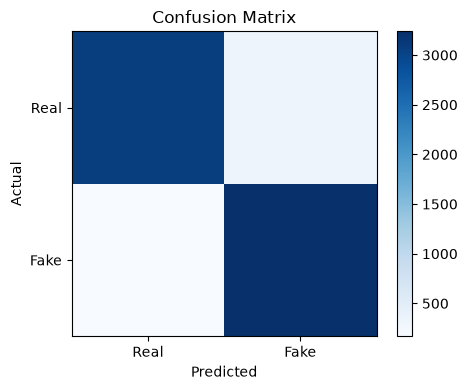

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- Make predictions on test data ---
y_pred = model.predict(X_test)                        # predict real or fake

# --- Print evaluation metrics ---
print("Model Evaluation:")
print(classification_report(y_test, y_pred,
      target_names=['Real', 'Fake']))                 # precision, recall, f1

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)                 # actual vs predicted
print("Confusion Matrix:")
print(cm)

# --- Plot confusion matrix ---
plt.figure(figsize=(5,4))                             # chart size
plt.imshow(cm, cmap='Blues')                          # blue color map
plt.title('Confusion Matrix')                         # title
plt.colorbar()                                        # color scale
plt.xlabel('Predicted')                               # x axis
plt.ylabel('Actual')                                  # y axis
plt.xticks([0,1], ['Real','Fake'])                    # x labels
plt.yticks([0,1], ['Real','Fake'])                    # y labels
plt.tight_layout()
plt.show()

In [8]:
import pickle
import os

# --- Create folder to save model ---
os.makedirs(r'C:\CareerShieldAI\ml_models', exist_ok=True)  # create folder if not exists

# --- Save trained model ---
with open(r'C:\CareerShieldAI\ml_models\fraud_model.pkl', 'wb') as f:
    pickle.dump(model, f)                             # save model to file

# --- Save TF-IDF vectorizer (needed to process new job postings) ---
with open(r'C:\CareerShieldAI\ml_models\tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)                             # save vectorizer to file

print("Model saved to ml_models/fraud_model.pkl")
print("Vectorizer saved to ml_models/tfidf_vectorizer.pkl")

Model saved to ml_models/fraud_model.pkl
Vectorizer saved to ml_models/tfidf_vectorizer.pkl
